<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_CLEAN_NATIVE_TABLES_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS V12 — Real 2dFLenS Foreground-Burden Weak-Lensing Test

Clean notebook built from scratch. It uses the actual 2dFLenS foreground lens catalogues, not the earlier LePhare fallback or stitched older cells.

Workflow:

1. Unpack the four 2dFLenS KiDS foreground-lens tarballs.
2. Load the four real foreground data catalogues and reject random catalogues.
3. Build real lens-bin burden proxies from the 2dFLenS foreground catalogues.
4. Download/load the KiDS-1000 `PneE` bandpower FITS and covariance.
5. Build ECSM geometry × real foreground burden × domain-boundary drivers.
6. Run full-data model competition.
7. Run held-out source-bin and lens-bin validation.
8. Export tables, figures, README, and ZIP outputs.

Author: Adam Sheldrick  
ORCID: https://orcid.org/0009-0004-3145-757X

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 00 — SETUP / IMPORTS / OUTPUT DIRECTORIES
import os, re, json, tarfile, shutil, subprocess, textwrap, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("default")

try:
    from astropy.io import fits
except Exception:
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "astropy", "-q"])
    from astropy.io import fits

try:
    from IPython.display import display, Markdown
except Exception:
    display = print

VERSION = "V12"
RUN_NAME = "ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden"
OUT = Path("/content/ecsm_kids_v12_real_2dflens_foreground_burden_out")
DATA = OUT / "data"
TAB = OUT / "tables"
FIG = OUT / "figures"
for d in [OUT, DATA, TAB, FIG]:
    d.mkdir(parents=True, exist_ok=True)

def banner(title):
    print("\n" + "="*72)
    print(title)
    print("="*72)

def save_json(obj, path):
    path = Path(path)
    path.write_text(json.dumps(obj, indent=2, default=str))
    print("Saved:", path)

def to_native_endian_array(x, copy=True):
    """Return a NumPy-2-safe native-endian array for FITS images/columns."""
    arr = np.asarray(x)
    if arr.dtype.isnative or arr.dtype.byteorder == '|':
        return np.array(arr, copy=copy)
    # NumPy 2 removed ndarray.newbyteorder(); use dtype.newbyteorder + view.
    return np.array(arr.byteswap().view(arr.dtype.newbyteorder('=')), copy=copy)

def fits_table_to_native_df(fits_data):
    """Convert a FITS_rec / table HDU data object to a pandas DataFrame with
    every column copied into native endian order.

    This avoids pandas failures such as:
        ValueError: Big-endian buffer not supported on little-endian compiler
    when selecting or slicing DataFrames created directly from FITS structured arrays.
    """
    names = list(getattr(fits_data, 'names', []) or [])
    if not names and hasattr(fits_data, 'dtype') and fits_data.dtype.names:
        names = list(fits_data.dtype.names)
    if not names:
        return pd.DataFrame(to_native_endian_array(fits_data, copy=True))
    cols = {}
    for name in names:
        cols[name] = to_native_endian_array(fits_data[name], copy=True)
    return pd.DataFrame(cols)

def as_float_array(x):
    arr = to_native_endian_array(x, copy=True)
    return np.asarray(arr, dtype=float)

banner("CELL 00 — SETUP COMPLETE")
print("Output directory:", OUT)


CELL 00 — SETUP COMPLETE
Output directory: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# CELL 01 — USER CONFIGURATION
banner("CELL 01 — USER CONFIGURATION")

# Four 2dFLenS foreground-lens catalogues supplied by user in Google Drive.
TARBALLS = {
    "z1_kidsn": "/content/drive/MyDrive/data_2dfbz1_kidsn_160105_rat.tar.gz",
    "z1_kidss": "/content/drive/MyDrive/data_2dfbz1_kidss_160105_rat.tar.gz",
    "z3_kidsn": "/content/drive/MyDrive/data_2dfbz3_kidsn_160105_rat.tar.gz",
    "z3_kidss": "/content/drive/MyDrive/data_2dfbz3_kidss_160105_rat.tar.gz",
}

# Public KiDS observation repository containing bandpower FITS products.
KIDS_REPO_URL = "https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1.git"
KIDS_REPO_DIR = DATA / "Cat_to_Obs_K1000_P1_repo"

# Main observable.
OBS_EXT = "PneE"

# Lens-bin definitions used by the KiDS/2dFLenS GGL bandpower product.
LENS_Z_EDGES = {1: (0.20, 0.50), 2: (0.50, 0.75)}

# Fixed response scales from the clean real-2dFLenS V12 construction.
# These are kept frozen for reproducibility rather than re-fitted as hidden degrees of freedom.
USE_FROZEN_ELLB = True
FROZEN_ELLB_BY_LENS = {1: 319.6985015837321, 2: 491.1517302249386}

# Model scan grids. These are intentionally small and explicit for auditability.
ALPHA_GRID = np.round(np.arange(0.30, 2.01, 0.025), 3)
P_GRID = [1.0, 2.0, 3.0, 4.0]
B_GRID = [-0.9, -0.75, -0.5, 0.0, 0.5]

for label, path in TARBALLS.items():
    print(f"{label}: {path} | exists={Path(path).exists()}")


CELL 01 — USER CONFIGURATION
z1_kidsn: /content/drive/MyDrive/data_2dfbz1_kidsn_160105_rat.tar.gz | exists=True
z1_kidss: /content/drive/MyDrive/data_2dfbz1_kidss_160105_rat.tar.gz | exists=True
z3_kidsn: /content/drive/MyDrive/data_2dfbz3_kidsn_160105_rat.tar.gz | exists=True
z3_kidss: /content/drive/MyDrive/data_2dfbz3_kidss_160105_rat.tar.gz | exists=True


In [4]:
# CELL 02 — UNPACK 2dFLenS KiDS-GGL FOREGROUND LENS CATALOGUES
banner("CELL 02 — UNPACK 2dFLenS KiDS-GGL FOREGROUND LENS CATALOGUES")

manifest_rows = []
EXTRACT_ROOT = DATA / "2dFLenS_foreground_catalogues_extracted"
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

for label, tar_path in TARBALLS.items():
    tar_path = Path(tar_path)
    if not tar_path.exists():
        raise FileNotFoundError(f"Missing tarball for {label}: {tar_path}")

    extract_dir = EXTRACT_ROOT / label
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nUnpacking {label}: {tar_path}")
    print("Size MB:", round(tar_path.stat().st_size / 1e6, 3))
    with tarfile.open(tar_path, "r:gz") as tar:
        members = tar.getmembers()
        print("Tar members:", len(members))
        tar.extractall(extract_dir)

    files = [p for p in extract_dir.rglob("*") if p.is_file()]
    print("Extracted files:", len(files))
    for p in files:
        manifest_rows.append({
            "label": label,
            "path": str(p),
            "name": p.name,
            "suffix": p.suffix,
            "size_mb": p.stat().st_size / 1e6,
            "relative_path": str(p.relative_to(EXTRACT_ROOT)),
        })

manifest = pd.DataFrame(manifest_rows).sort_values(["label", "name"]).reset_index(drop=True)
manifest.to_csv(TAB / "v12_2dflens_tarball_manifest.csv", index=False)
print("Saved manifest:", TAB / "v12_2dflens_tarball_manifest.csv")
display(manifest.head(20))
print("Total files:", len(manifest))


CELL 02 — UNPACK 2dFLenS KiDS-GGL FOREGROUND LENS CATALOGUES

Unpacking z1_kidsn: /content/drive/MyDrive/data_2dfbz1_kidsn_160105_rat.tar.gz
Size MB: 12.501
Tar members: 101


/tmp/ipykernel_1690/4035659904.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extracted files: 101

Unpacking z1_kidss: /content/drive/MyDrive/data_2dfbz1_kidss_160105_rat.tar.gz
Size MB: 30.998
Tar members: 101
Extracted files: 101

Unpacking z3_kidsn: /content/drive/MyDrive/data_2dfbz3_kidsn_160105_rat.tar.gz
Size MB: 8.763
Tar members: 101
Extracted files: 101

Unpacking z3_kidss: /content/drive/MyDrive/data_2dfbz3_kidss_160105_rat.tar.gz
Size MB: 32.365
Tar members: 101
Extracted files: 101
Saved manifest: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_tarball_manifest.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,label,path,name,suffix,size_mb,relative_path
0,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat
1,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand001_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand001_bz1_atlas_kidsn_160105_see_ex...
2,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand002_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand002_bz1_atlas_kidsn_160105_see_ex...
3,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand003_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand003_bz1_atlas_kidsn_160105_see_ex...
4,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand004_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand004_bz1_atlas_kidsn_160105_see_ex...
5,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand005_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand005_bz1_atlas_kidsn_160105_see_ex...
6,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand006_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand006_bz1_atlas_kidsn_160105_see_ex...
7,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand007_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand007_bz1_atlas_kidsn_160105_see_ex...
8,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand008_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand008_bz1_atlas_kidsn_160105_see_ex...
9,z1_kidsn,/content/ecsm_kids_v12_real_2dflens_foreground...,rand009_bz1_atlas_kidsn_160105_see_exp.dat,.dat,0.323649,z1_kidsn/rand009_bz1_atlas_kidsn_160105_see_ex...


Total files: 404


In [5]:
# CELL 03 — IDENTIFY 2dFLenS DATA VS RANDOM CATALOGUES
banner("CELL 03 — IDENTIFY 2dFLenS DATA VS RANDOM CATALOGUES")

rows = []
for p in sorted(EXTRACT_ROOT.rglob("*.dat")):
    name = p.name.lower()
    rel = str(p.relative_to(EXTRACT_ROOT))
    is_data = name.startswith("data_")
    is_random = name.startswith("rand")
    lens_bin = 1 if "bz1" in name else (2 if "bz3" in name else None)
    z_label = "z1" if "bz1" in name else ("z3" if "bz3" in name else None)
    field = "kidsn" if "kidsn" in name else ("kidss" if "kidss" in name else None)
    rows.append({
        "path": str(p), "name": p.name, "relative_path": rel,
        "size_mb": p.stat().st_size/1e6,
        "is_data_candidate": is_data,
        "is_random": is_random,
        "lens_bin": lens_bin,
        "z_label": z_label,
        "field": field,
    })

dat_audit = pd.DataFrame(rows)
dat_audit.to_csv(TAB / "v12_2dflens_dat_file_audit.csv", index=False)
print("DAT files audited:", len(dat_audit))
print("Data candidates:", int(dat_audit["is_data_candidate"].sum()))
print("Random catalogues:", int(dat_audit["is_random"].sum()))
display(dat_audit.head(40))

DATA_CANDIDATES = dat_audit[dat_audit["is_data_candidate"]].copy().sort_values(["lens_bin", "field"])
print("\nLikely foreground data catalogues:")
display(DATA_CANDIDATES)

if len(DATA_CANDIDATES) != 4:
    raise RuntimeError(f"Expected four data catalogues, found {len(DATA_CANDIDATES)}")


CELL 03 — IDENTIFY 2dFLenS DATA VS RANDOM CATALOGUES
DAT files audited: 404
Data candidates: 4
Random catalogues: 400


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,path,name,relative_path,size_mb,is_data_candidate,is_random,lens_bin,z_label,field
0,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat,0.323649,True,False,1,z1,kidsn
1,/content/ecsm_kids_v12_real_2dflens_foreground...,rand001_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand001_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
2,/content/ecsm_kids_v12_real_2dflens_foreground...,rand002_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand002_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
3,/content/ecsm_kids_v12_real_2dflens_foreground...,rand003_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand003_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
4,/content/ecsm_kids_v12_real_2dflens_foreground...,rand004_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand004_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
5,/content/ecsm_kids_v12_real_2dflens_foreground...,rand005_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand005_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
6,/content/ecsm_kids_v12_real_2dflens_foreground...,rand006_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand006_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
7,/content/ecsm_kids_v12_real_2dflens_foreground...,rand007_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand007_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
8,/content/ecsm_kids_v12_real_2dflens_foreground...,rand008_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand008_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn
9,/content/ecsm_kids_v12_real_2dflens_foreground...,rand009_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/rand009_bz1_atlas_kidsn_160105_see_ex...,0.323649,False,True,1,z1,kidsn



Likely foreground data catalogues:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,path,name,relative_path,size_mb,is_data_candidate,is_random,lens_bin,z_label,field
0,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat,0.323649,True,False,1,z1,kidsn
101,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidss_160105_rat.dat,z1_kidss/data_bz1_atlas_kidss_160105_rat.dat,0.791107,True,False,1,z1,kidss
202,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz3_atlas_kidsn_160105_see_exp.dat,z3_kidsn/data_bz3_atlas_kidsn_160105_see_exp.dat,0.225525,True,False,2,z3,kidsn
303,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz3_atlas_kidss_160105_rat.dat,z3_kidss/data_bz3_atlas_kidss_160105_rat.dat,0.825665,True,False,2,z3,kidss


In [6]:
# CELL 04 — RAW-LINE INSPECTION AND ROBUST 2dFLenS DATA-CATALOGUE LOADER
banner("CELL 04 — RAW-LINE INSPECTION AND ROBUST 2dFLenS DATA-CATALOGUE LOADER")

def line_tokens_numeric(line):
    toks = line.strip().split()
    if not toks:
        return False, 0
    try:
        [float(t) for t in toks]
        return True, len(toks)
    except Exception:
        return False, len(toks)

def find_numeric_start(path):
    with open(path, "r", errors="ignore") as f:
        for i, line in enumerate(f, start=1):
            ok, n = line_tokens_numeric(line)
            if ok and n >= 6:
                return i
    raise ValueError(f"No numeric table found in {path}")

def preview_lines(path, n=18):
    out=[]
    with open(path, "r", errors="ignore") as f:
        for i, line in zip(range(1, n+1), f):
            ok, ntok = line_tokens_numeric(line)
            out.append({"line_no": i, "raw": line.rstrip("\n")[:160], "looks_numeric": ok, "n_tokens": ntok, "file": Path(path).name})
    return pd.DataFrame(out)

def load_2dflens_dat(path):
    start = find_numeric_start(path)
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None, skiprows=start-1, engine="python")
    if df.shape[1] < 10:
        raise ValueError(f"Expected >=10 columns in {path}, got {df.shape[1]}")
    # Header says: RA Dec redshift x[Mpc/h] y[Mpc/h] z[Mpc/h] weight jackknife type tile
    names = ["RA", "DEC", "redshift", "x_mpc_h", "y_mpc_h", "z_mpc_h", "fkp_weight", "jackknife_region", "target_type", "tile_id"]
    df = df.iloc[:, :10].copy()
    df.columns = names
    return start, df

preview_frames = []
summary_rows = []
cat_frames = []

print("Foreground data candidates:", len(DATA_CANDIDATES))
for _, row in DATA_CANDIDATES.iterrows():
    p = Path(row["path"])
    print("\n" + "-"*72)
    print("Inspecting:", p.name)
    print("Relative:", row["relative_path"])
    prev = preview_lines(p)
    preview_frames.append(prev)
    display(prev)

    start, df = load_2dflens_dat(p)
    print("Numeric table starts at line:", start)
    print("Loaded shape:", df.shape)
    display(df.head())

    for k in ["field", "z_label", "lens_bin"]:
        pass
    df["source_file"] = p.name
    df["field"] = row["field"]
    df["z_label"] = row["z_label"]
    df["lens_bin"] = int(row["lens_bin"])
    df["in_expected_z_range"] = df.apply(lambda r: LENS_Z_EDGES[int(r["lens_bin"])][0] <= r["redshift"] <= LENS_Z_EDGES[int(r["lens_bin"])][1], axis=1)
    cat_frames.append(df)

    info = {
        "path": str(p), "name": p.name, "relative_path": row["relative_path"],
        "field": row["field"], "z_label": row["z_label"], "lens_bin": int(row["lens_bin"]),
        "numeric_start_line_1indexed": start, "n_rows": len(df), "n_cols": df.shape[1],
        "z_min": float(df["redshift"].min()), "z_max": float(df["redshift"].max()), "z_mean": float(df["redshift"].mean()),
        "weight_sum": float(df["fkp_weight"].sum()), "weight_mean": float(df["fkp_weight"].mean()),
    }
    summary_rows.append(info)

raw_previews = pd.concat(preview_frames, ignore_index=True)
loader_summary = pd.DataFrame(summary_rows)
foreground = pd.concat(cat_frames, ignore_index=True)

raw_previews.to_csv(TAB / "v12_2dflens_raw_line_previews.csv", index=False)
loader_summary.to_csv(TAB / "v12_2dflens_data_loader_summary.csv", index=False)
foreground.to_csv(TAB / "v12_2dflens_foreground_loaded_numeric_catalogues.csv", index=False)

print("\nCombined foreground catalogue rows:", len(foreground))
print("Saved raw previews:", TAB / "v12_2dflens_raw_line_previews.csv")
print("Saved loader summary:", TAB / "v12_2dflens_data_loader_summary.csv")
print("Saved combined foreground catalogue:", TAB / "v12_2dflens_foreground_loaded_numeric_catalogues.csv")
display(loader_summary)
display(foreground.head())


CELL 04 — RAW-LINE INSPECTION AND ROBUST 2dFLenS DATA-CATALOGUE LOADER
Foreground data candidates: 4

------------------------------------------------------------------------
Inspecting: data_bz1_atlas_kidsn_160105_see_exp.dat
Relative: z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,line_no,raw,looks_numeric,n_tokens,file
0,1,4372 2,True,2,data_bz1_atlas_kidsn_160105_see_exp.dat
1,2,# RA Dec redshift x[Mpc/h] y[Mpc/h] z[Mpc/h] w...,False,11,data_bz1_atlas_kidsn_160105_see_exp.dat
2,3,# type=1-LOWZ 2-CMASS 3-eBOSS,False,4,data_bz1_atlas_kidsn_160105_see_exp.dat
3,4,166.433975 -10.634514 0.22631 568.64 -294.1...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
4,5,166.181808 -10.545737 0.22343 560.59 -293.1...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
5,6,164.412338 -10.533814 0.38774 917.12 -515.7...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
6,7,166.143845 -10.516605 0.21275 535.06 -280.2...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
7,8,166.175766 -10.506906 0.33684 820.94 -429.4...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
8,9,164.201416 -10.490175 0.33447 800.59 -454.0...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat
9,10,164.228561 -10.483822 0.38899 918.17 -520.1...,True,10,data_bz1_atlas_kidsn_160105_see_exp.dat


Numeric table starts at line: 4
Loaded shape: (4372, 10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...


Combined foreground catalogue rows: 29263
Saved raw previews: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_raw_line_previews.csv
Saved loader summary: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_data_loader_summary.csv
Saved combined foreground catalogue: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_foreground_loaded_numeric_catalogues.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,path,name,relative_path,field,z_label,lens_bin,numeric_start_line_1indexed,n_rows,n_cols,z_min,z_max,z_mean,weight_sum,weight_mean
0,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidsn_160105_see_exp.dat,z1_kidsn/data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,4,4372,15,0.20036,0.49995,0.360473,1378.4853,0.315299
1,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz1_atlas_kidss_160105_rat.dat,z1_kidss/data_bz1_atlas_kidss_160105_rat.dat,kidss,z1,1,4,10689,15,0.20001,0.49998,0.362526,3549.4069,0.332062
2,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz3_atlas_kidsn_160105_see_exp.dat,z3_kidsn/data_bz3_atlas_kidsn_160105_see_exp.dat,kidsn,z3,2,4,3046,15,0.50003,0.74988,0.592745,1422.7119,0.467075
3,/content/ecsm_kids_v12_real_2dflens_foreground...,data_bz3_atlas_kidss_160105_rat.dat,z3_kidss/data_bz3_atlas_kidss_160105_rat.dat,kidss,z3,2,4,11156,15,0.50001,0.74998,0.601991,4777.5773,0.428252


,RA,DEC,redshift,x_mpc_h,y_mpc_h,z_mpc_h,fkp_weight,jackknife_region,target_type,tile_id,source_file,field,z_label,lens_bin,in_expected_z_range
0,166.433975,-10.634514,0.22631,568.64,-294.16,-55.89,0.3226,3,1,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True
1,166.181808,-10.545737,0.22343,560.59,-293.14,-54.38,0.3629,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True
2,164.412338,-10.533814,0.38774,917.12,-515.72,-91.95,0.3393,1,1,40,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True
3,166.143845,-10.516605,0.21275,535.06,-280.25,-51.63,0.5712,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True
4,166.175766,-10.506906,0.33684,820.94,-429.42,-79.01,0.3786,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# CELL 05 — BUILD REAL 2dFLenS FOREGROUND-LENS BURDEN TABLE
banner("CELL 05 — BUILD REAL 2dFLenS FOREGROUND-LENS BURDEN TABLE")

fg = foreground.copy()
fg = fg[np.isfinite(fg["RA"]) & np.isfinite(fg["DEC"]) & np.isfinite(fg["redshift"]) & np.isfinite(fg["fkp_weight"])].copy()
fg = fg[fg["in_expected_z_range"]].copy()
print("Foreground clean rows:", len(fg))

# Radial proxy from supplied comoving coordinates. This is not a mass; it is used only as a compactness/concentration proxy.
fg["r_mpc_h"] = np.sqrt(fg["x_mpc_h"]**2 + fg["y_mpc_h"]**2 + fg["z_mpc_h"]**2)

field_rows=[]
for (lens_bin, field), sub in fg.groupby(["lens_bin", "field"]):
    w = sub["fkp_weight"].astype(float).values
    z = sub["redshift"].astype(float).values
    r = sub["r_mpc_h"].astype(float).values
    field_rows.append({
        "lens_bin": int(lens_bin), "field": field,
        "n_lenses": int(len(sub)),
        "sum_fkp_weight": float(w.sum()),
        "mean_fkp_weight": float(w.mean()),
        "z_min": float(z.min()), "z_max": float(z.max()),
        "z_mean": float(z.mean()),
        "z_weighted_mean": float(np.average(z, weights=w)),
        "ra_min": float(sub["RA"].min()), "ra_max": float(sub["RA"].max()),
        "dec_min": float(sub["DEC"].min()), "dec_max": float(sub["DEC"].max()),
        "r_rms_mpc_h": float(np.sqrt(np.mean(r**2))),
        "spatial_concentration_raw": float(1.0 / np.maximum(np.sqrt(np.mean(r**2)), 1e-12)),
        "frac_expected_z_range": float(sub["in_expected_z_range"].mean()),
        "frac_LOWZ_type1": float((sub["target_type"] == 1).mean()),
        "frac_CMASS_type2": float((sub["target_type"] == 2).mean()),
        "frac_eBOSS_type3": float((sub["target_type"] == 3).mean()),
    })
field_burden = pd.DataFrame(field_rows).sort_values(["lens_bin", "field"]).reset_index(drop=True)

lens_rows=[]
for lens_bin, sub in fg.groupby("lens_bin"):
    w = sub["fkp_weight"].astype(float).values
    z = sub["redshift"].astype(float).values
    r = sub["r_mpc_h"].astype(float).values
    n = len(sub)
    sumw = float(w.sum())
    rrms = float(np.sqrt(np.mean(r**2)))
    conc = float(1.0 / np.maximum(rrms, 1e-12))
    lens_rows.append({
        "lens_bin": int(lens_bin),
        "n_lenses": int(n),
        "sum_fkp_weight": sumw,
        "mean_fkp_weight": float(w.mean()),
        "z_min": float(z.min()), "z_max": float(z.max()),
        "z_mean": float(z.mean()),
        "z_weighted_mean": float(np.average(z, weights=w)),
        "r_rms_mpc_h": rrms,
        "spatial_concentration_raw": conc,
        "number_burden_raw": float(n),
        "weighted_burden_raw": sumw,
        "density_burden_raw": float(sumw * conc),
        "frac_expected_z_range": float(sub["in_expected_z_range"].mean()),
        "frac_LOWZ_type1": float((sub["target_type"] == 1).mean()),
        "frac_CMASS_type2": float((sub["target_type"] == 2).mean()),
        "frac_eBOSS_type3": float((sub["target_type"] == 3).mean()),
    })
lens_burden = pd.DataFrame(lens_rows).sort_values("lens_bin").reset_index(drop=True)

# Normalize each burden to mean 1 across the two foreground lens bins.
for raw, norm in [
    ("number_burden_raw", "number_burden_norm"),
    ("weighted_burden_raw", "weighted_burden_norm"),
    ("density_burden_raw", "density_burden_norm"),
    ("spatial_concentration_raw", "spatial_concentration_norm"),
]:
    lens_burden[norm] = lens_burden[raw] / lens_burden[raw].mean()

catalogue_burden_norm = dict(zip(lens_burden["lens_bin"], lens_burden["weighted_burden_norm"]))
catalogue_density_burden_norm = dict(zip(lens_burden["lens_bin"], lens_burden["density_burden_norm"]))
catalogue_number_burden_norm = dict(zip(lens_burden["lens_bin"], lens_burden["number_burden_norm"]))
catalogue_concentration_norm = dict(zip(lens_burden["lens_bin"], lens_burden["spatial_concentration_norm"]))

print("Catalogue burden norm:", catalogue_burden_norm)
print("Catalogue density burden norm:", catalogue_density_burden_norm)
print("Catalogue number burden norm:", catalogue_number_burden_norm)
print("Catalogue concentration norm:", catalogue_concentration_norm)

field_burden.to_csv(TAB / "v12_2dflens_field_level_foreground_burden.csv", index=False)
lens_burden.to_csv(TAB / "v12_2dflens_lensbin_foreground_burden.csv", index=False)
fg.to_csv(TAB / "v12_2dflens_foreground_catalogue_clean_named.csv", index=False)
print("Saved:", TAB / "v12_2dflens_field_level_foreground_burden.csv")
print("Saved:", TAB / "v12_2dflens_lensbin_foreground_burden.csv")
print("Saved:", TAB / "v12_2dflens_foreground_catalogue_clean_named.csv")
display(field_burden)
display(lens_burden)
display(fg.head())


CELL 05 — BUILD REAL 2dFLenS FOREGROUND-LENS BURDEN TABLE
Foreground clean rows: 29263
Catalogue burden norm: {1: 0.8856599336168263, 2: 1.1143400663831737}
Catalogue density burden norm: {1: 1.0977723988540242, 2: 0.9022276011459759}
Catalogue number burden norm: {1: 1.0293544749342172, 2: 0.9706455250657827}
Catalogue concentration norm: {1: 1.2097674118694484, 2: 0.7902325881305516}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_field_level_foreground_burden.csv
Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_lensbin_foreground_burden.csv
Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_2dflens_foreground_catalogue_clean_named.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,lens_bin,field,n_lenses,sum_fkp_weight,mean_fkp_weight,z_min,z_max,z_mean,z_weighted_mean,ra_min,ra_max,dec_min,dec_max,r_rms_mpc_h,spatial_concentration_raw,frac_expected_z_range,frac_LOWZ_type1,frac_CMASS_type2,frac_eBOSS_type3
0,1,kidsn,4372,1378.4853,0.315299,0.20036,0.49995,0.360473,0.370627,155.587433,232.794632,-10.634514,-2.098802,1006.504134,0.000994,1.0,0.619625,0.372141,0.008234
1,1,kidss,10689,3549.4069,0.332062,0.20001,0.49998,0.362526,0.376522,0.003782,359.991425,-35.728100,-26.253115,1013.020287,0.000987,1.0,0.659276,0.333146,0.007578
2,2,kidsn,3046,1422.7119,0.467075,0.50003,0.74988,0.592745,0.607746,155.546799,232.679718,-10.542426,-2.134512,1532.229992,0.000653,1.0,0.007879,0.738674,0.253447
3,2,kidss,11156,4777.5773,0.428252,0.50001,0.74998,0.601991,0.614989,0.009400,359.993683,-35.743065,-26.278383,1552.206914,0.000644,1.0,0.006723,0.665920,0.327357


,lens_bin,n_lenses,sum_fkp_weight,mean_fkp_weight,z_min,z_max,z_mean,z_weighted_mean,r_rms_mpc_h,spatial_concentration_raw,...,weighted_burden_raw,density_burden_raw,frac_expected_z_range,frac_LOWZ_type1,frac_CMASS_type2,frac_eBOSS_type3,number_burden_norm,weighted_burden_norm,density_burden_norm,spatial_concentration_norm
0,1,15061,4927.8922,0.327196,0.20001,0.49998,0.361930,0.374873,1011.133063,0.000989,...,4927.8922,4.873634,1.0,0.647766,0.344466,0.007768,1.029354,0.88566,1.097772,1.209767
1,2,14202,6200.2892,0.436579,0.50001,0.74998,0.600008,0.613327,1547.944045,0.000646,...,6200.2892,4.005500,1.0,0.006971,0.681524,0.311505,0.970646,1.11434,0.902228,0.790233


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,RA,DEC,redshift,x_mpc_h,y_mpc_h,z_mpc_h,fkp_weight,jackknife_region,target_type,tile_id,source_file,field,z_label,lens_bin,in_expected_z_range,r_mpc_h
0,166.433975,-10.634514,0.22631,568.64,-294.16,-55.89,0.3226,3,1,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True,642.654843
1,166.181808,-10.545737,0.22343,560.59,-293.14,-54.38,0.3629,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True,634.940463
2,164.412338,-10.533814,0.38774,917.12,-515.72,-91.95,0.3393,1,1,40,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True,1056.187017
3,166.143845,-10.516605,0.21275,535.06,-280.25,-51.63,0.5712,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True,606.213595
4,166.175766,-10.506906,0.33684,820.94,-429.42,-79.01,0.3786,3,2,58,data_bz1_atlas_kidsn_160105_see_exp.dat,kidsn,z1,1,True,929.831490


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# CELL 06 — LOAD KiDS PneE + BUILD GEOMETRY × REAL 2dFLenS BURDEN × DOMAIN DRIVERS
banner("CELL 06 — LOAD KiDS PneE + BUILD GEOMETRY × REAL 2dFLenS BURDEN × DOMAIN DRIVERS")

if not KIDS_REPO_DIR.exists():
    print("Downloading KiDS Cat_to_Obs_K1000_P1 repository...")
    subprocess.run(["git", "clone", "--depth", "1", KIDS_REPO_URL, str(KIDS_REPO_DIR)], check=True)
else:
    print("Using existing KiDS repo:", KIDS_REPO_DIR)

fits_paths = sorted(KIDS_REPO_DIR.rglob("*.fits"))
print("FITS files found:", len(fits_paths))

cand=[]
for p in fits_paths:
    try:
        with fits.open(p, memmap=False) as hdul:
            names = [h.name for h in hdul]
        score = 0
        low = p.name.lower()
        if low.startswith("bp_"): score += 20
        if "blindc" in low: score += 10
        if "no_m_bias" in low: score += 10
        if "bmodes" not in low: score += 5
        if all(x in names for x in ["COVMAT", "PneE", "NZ_LENS", "NZ_SOURCE"]): score += 20
        cand.append((score, p, names))
    except Exception:
        pass
cand = sorted(cand, key=lambda x: x[0], reverse=True)
print("Top candidates:")
for score, p, names in cand[:8]:
    print(f"score {score:>3} | {p.name} | {names}")

if not cand:
    raise FileNotFoundError("No KiDS FITS candidates found.")
fits_path = cand[0][1]
print("Using FITS:", fits_path)

with fits.open(fits_path, memmap=False) as hdul:
    hdul.info()
    pnee = fits_table_to_native_df(hdul["PneE"].data)
    cov_full = as_float_array(hdul["COVMAT"].data)
    nz_lens = fits_table_to_native_df(hdul["NZ_LENS"].data)
    nz_source = fits_table_to_native_df(hdul["NZ_SOURCE"].data)

print("PneE columns:", list(pnee.columns))
print("NZ_LENS columns:", list(nz_lens.columns))
print("NZ_SOURCE columns:", list(nz_source.columns))

# KiDS bandpower vector: columns BIN1, BIN2, ANGBIN, VALUE, ANG.
kids = pnee.rename(columns={"BIN1":"lens_bin", "BIN2":"source_bin", "ANGBIN":"ell_bin", "VALUE":"Pgk_E", "ANG":"ell"}).copy()
kids = kids[["lens_bin", "source_bin", "ell_bin", "Pgk_E", "ell"]]
kids["lens_bin"] = kids["lens_bin"].astype(int)
kids["source_bin"] = kids["source_bin"].astype(int)
kids["ell_bin"] = kids["ell_bin"].astype(int)
kids["vec_index"] = np.arange(len(kids))

# COVMAT in the FITS is for multiple observables; PneE is first 80 rows/columns in this product.
N = len(kids)
cov = np.asarray(cov_full[:N, :N], dtype=float)
kids["sigma_diag"] = np.sqrt(np.clip(np.diag(cov), 0, np.inf))

for lb, (zlo,zhi) in LENS_Z_EDGES.items():
    mask = kids["lens_bin"] == lb
    kids.loc[mask, "lens_z_min"] = zlo
    kids.loc[mask, "lens_z_max"] = zhi
    kids.loc[mask, "lens_z_eff_simple"] = 0.5*(zlo+zhi)

print("N:", len(kids), "Covariance:", cov.shape)
display(kids.head())

# n(z) helpers.
def nz_moments(table, bin_col):
    z = table["Z_MID"].astype(float).values if "Z_MID" in table.columns else 0.5*(table["Z_LOW"].astype(float).values + table["Z_HIGH"].astype(float).values)
    n = table[bin_col].astype(float).values
    n = np.clip(n, 0, np.inf)
    area = np.trapezoid(n, z)
    if not np.isfinite(area) or area <= 0:
        return {"z_mean": np.nan, "sigma_z": np.nan, "area": area, "z": z, "n_norm": n*0}
    nn = n / area
    mu = np.trapezoid(z*nn, z)
    var = np.trapezoid(((z-mu)**2)*nn, z)
    return {"z_mean": float(mu), "sigma_z": float(np.sqrt(max(var,0))), "area": float(area), "z": z, "n_norm": nn}

def lens_source_G(lens_m, source_m):
    zl, nl = lens_m["z"], lens_m["n_norm"]
    zs, ns = source_m["z"], source_m["n_norm"]
    eff=[]
    for z_l in zl:
        sep = np.maximum(zs - z_l, 0.0)
        eff.append(np.trapezoid(ns * sep / np.maximum(zs, 1e-8), zs))
    return float(np.trapezoid(nl * np.asarray(eff), zl))

lens_cols = [c for c in nz_lens.columns if re.fullmatch(r"BIN\d+", str(c))]
source_cols = [c for c in nz_source.columns if re.fullmatch(r"BIN\d+", str(c))]
print("Lens n(z) columns:", lens_cols)
print("Source n(z) columns:", source_cols)

lens_m = {int(c.replace("BIN", "")): nz_moments(nz_lens, c) for c in lens_cols}
source_m = {int(c.replace("BIN", "")): nz_moments(nz_source, c) for c in source_cols}

geom_rows=[]
for lb in sorted(kids["lens_bin"].unique()):
    for sb in sorted(kids["source_bin"].unique()):
        lm, sm = lens_m[int(lb)], source_m[int(sb)]
        G = lens_source_G(lm, sm)
        zl, zs = lm["z_mean"], sm["z_mean"]
        sl, ss = lm["sigma_z"], sm["sigma_z"]
        denom = max(np.sqrt(sl**2 + ss**2), 1e-12)
        raw_grad = max(0.0, (zs - zl) / denom)
        chi_grad = raw_grad / (1.0 + raw_grad)
        conc = float(catalogue_concentration_norm.get(int(lb), 1.0))
        wbur = float(catalogue_burden_norm.get(int(lb), 1.0))
        dbur = float(catalogue_density_burden_norm.get(int(lb), 1.0))
        nbur = float(catalogue_number_burden_norm.get(int(lb), 1.0))
        ext = G * conc
        gw = ext * wbur
        gd = ext * dbur
        gn = ext * nbur
        geom_rows.append({
            "lens_bin": int(lb), "source_bin": int(sb),
            "G_lens_source": G,
            "z_lens_mean": zl, "z_source_mean": zs,
            "sigma_z_lens": sl, "sigma_z_source": ss,
            "catalogue_weighted_burden_norm": wbur,
            "catalogue_density_burden_norm": dbur,
            "catalogue_number_burden_norm": nbur,
            "catalogue_concentration_norm": conc,
            "domain_boundary_gradient_raw": raw_grad,
            "domain_boundary_gradient_chi": chi_grad,
            "external_geometry_driver": ext,
            "geometry_weighted_burden_driver": gw,
            "geometry_density_burden_driver": gd,
            "geometry_number_burden_driver": gn,
            "domain_gradient_driver": gw * chi_grad,
            "combined_weighted_driver": gw * (1.0 + chi_grad),
            "combined_density_driver": gd * (1.0 + chi_grad),
            "combined_number_driver": gn * (1.0 + chi_grad),
        })
geom = pd.DataFrame(geom_rows)

kids_drv = kids.merge(geom, on=["lens_bin", "source_bin"], how="left")
ell0 = float(np.sqrt(float(kids_drv["ell"].min()) * float(kids_drv["ell"].max())))
if USE_FROZEN_ELLB:
    ellB_by_lens = {int(k): float(v) for k,v in FROZEN_ELLB_BY_LENS.items()}
else:
    ellB_by_lens = {int(lb): ell0 for lb in sorted(kids_drv["lens_bin"].unique())}

print("ell0:", ell0)
print("ellB_by_lens:", ellB_by_lens)

kids.to_csv(TAB / "v12_kids_pnee_bandpower_table.csv", index=False)
pd.DataFrame(cov).to_csv(TAB / "v12_kids_pnee_covariance.csv", index=False, header=False)
geom.to_csv(TAB / "v12_geometry_real_2dflens_burden_domain_drivers.csv", index=False)
kids_drv.to_csv(TAB / "v12_kids_pnee_with_real_2dflens_drivers.csv", index=False)
save_json(ellB_by_lens, TAB / "v12_ellB_by_lens.json")
print("Saved bandpower, covariance, geometry, and driver tables.")
display(geom)
display(kids_drv.head())


CELL 06 — LOAD KiDS PneE + BUILD GEOMETRY × REAL 2dFLenS BURDEN × DOMAIN DRIVERS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


FITS files found: 29
Top candidates:
score  65 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score  65 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score  55 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score  55 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score  50 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35


Lens n(z) columns: ['BIN1', 'BIN2']
Source n(z) columns: ['BIN1', 'BIN2', 'BIN3', 'BIN4', 'BIN5']
ell0: 387.29833462074174
ellB_by_lens: {1: 319.6985015837321, 2: 491.1517302249386}
Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_ellB_by_lens.json
Saved bandpower, covariance, geometry, and driver tables.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,lens_bin,source_bin,G_lens_source,z_lens_mean,z_source_mean,sigma_z_lens,sigma_z_source,catalogue_weighted_burden_norm,catalogue_density_burden_norm,catalogue_number_burden_norm,...,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_weighted_burden_driver,geometry_density_burden_driver,geometry_number_burden_driver,domain_gradient_driver,combined_weighted_driver,combined_density_driver,combined_number_driver
0,1,1,0.039128,0.385031,0.257918,0.085667,0.161204,0.88566,1.097772,1.029354,...,0.000000,0.000000,0.047336,0.041923,0.051964,0.048725,0.000000,0.041923,0.051964,0.048725
1,1,2,0.127750,0.385031,0.402965,0.085667,0.158368,0.88566,1.097772,1.029354,...,0.099606,0.090584,0.154548,0.136877,0.169659,0.159085,0.012399,0.149276,0.185027,0.173495
2,1,3,0.298699,0.385031,0.563835,0.085667,0.201769,0.88566,1.097772,1.029354,...,0.815705,0.449250,0.361357,0.320039,0.396688,0.371964,0.143778,0.463817,0.574899,0.539069
3,1,4,0.498084,0.385031,0.792016,0.085667,0.159063,0.88566,1.097772,1.029354,...,2.252708,0.692564,0.602566,0.533669,0.661480,0.620254,0.369600,0.903268,1.119598,1.049820
4,1,5,0.586664,0.385031,0.983770,0.085667,0.249781,0.88566,1.097772,1.029354,...,2.267406,0.693947,0.709727,0.628577,0.779119,0.730561,0.436199,1.064775,1.319785,1.237531
5,2,1,0.007021,0.586194,0.257918,0.060051,0.161204,1.11434,0.902228,0.970646,...,0.000000,0.000000,0.005548,0.006183,0.005006,0.005385,0.000000,0.006183,0.005006,0.005385
6,2,2,0.010401,0.586194,0.402965,0.060051,0.158368,1.11434,0.902228,0.970646,...,0.000000,0.000000,0.008219,0.009159,0.007415,0.007978,0.000000,0.009159,0.007415,0.007978
7,2,3,0.070281,0.586194,0.563835,0.060051,0.201769,1.11434,0.902228,0.970646,...,0.000000,0.000000,0.055538,0.061888,0.050108,0.053908,0.000000,0.061888,0.050108,0.053908
8,2,4,0.245663,0.586194,0.792016,0.060051,0.159063,1.11434,0.902228,0.970646,...,1.210570,0.547628,0.194131,0.216328,0.175150,0.188432,0.118467,0.334795,0.271068,0.291623
9,2,5,0.376082,0.586194,0.983770,0.060051,0.249781,1.11434,0.902228,0.970646,...,1.547600,0.607474,0.297192,0.331173,0.268135,0.288468,0.201179,0.532352,0.431020,0.463705


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple,...,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_weighted_burden_driver,geometry_density_burden_driver,geometry_number_burden_driver,domain_gradient_driver,combined_weighted_driver,combined_density_driver,combined_number_driver
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# CELL 07 — FULL-DATA MODEL COMPETITION WITH REAL 2dFLenS FOREGROUND BURDEN
banner("CELL 07 — FULL-DATA MODEL COMPETITION WITH REAL 2dFLenS FOREGROUND BURDEN")

kids_model = kids_drv.copy().reset_index(drop=True)
y = kids_model["Pgk_E"].values.astype(float)
ell = kids_model["ell"].values.astype(float)
lens_bins_vec = kids_model["lens_bin"].values.astype(int)

# Covariance cleanup and inverse/cholesky utilities.
cov = pd.read_csv(TAB / "v12_kids_pnee_covariance.csv", header=None).values.astype(float)
if cov.shape == (len(kids_model)+1, len(kids_model)):
    print("Detected extra covariance header row; dropping first row.")
    cov = cov[1:, :]
if cov.shape != (len(kids_model), len(kids_model)):
    raise ValueError(f"Data/covariance mismatch: N={len(kids_model)}, cov={cov.shape}")

# Small jitter for numerical safety.
cov = 0.5*(cov + cov.T)
jitter = 0.0
for j in [0.0, 1e-14, 1e-12, 1e-10, 1e-8]:
    try:
        L = np.linalg.cholesky(cov + np.eye(len(cov))*j)
        jitter = j
        break
    except np.linalg.LinAlgError:
        L = None
if L is not None:
    Cinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(cov))))
    cov_method = "cholesky"
else:
    Cinv = np.linalg.pinv(cov)
    cov_method = "pinv"
print("N:", len(kids_model))
print("ell0:", ell0)
print("ellB_by_lens:", ellB_by_lens)
print("Covariance method:", cov_method, "jitter:", jitter)

def finite_kernel(ell, lens_bin, p=2.0, B=0.0):
    ellB = np.array([ellB_by_lens[int(lb)] for lb in lens_bin], dtype=float)
    return (1.0 + (ell / np.maximum(ellB, 1e-12))**p)**B

def template_from_driver(driver, alpha=1.0, p=2.0, B=0.0):
    driver = np.asarray(driver, dtype=float)
    return driver * (ell/ell0)**alpha * finite_kernel(ell, lens_bins_vec, p=p, B=B)

def fit_amplitude(template, y, Cinv):
    t = np.asarray(template, dtype=float)
    denom = float(t @ Cinv @ t)
    if not np.isfinite(denom) or denom <= 0:
        return 0.0, np.inf, np.zeros_like(t)
    A = float((t @ Cinv @ y) / denom)
    pred = A * t
    r = y - pred
    chi2 = float(r @ Cinv @ r)
    return A, chi2, pred

def chi2_of_pred(pred, y, Cinv):
    r = y - pred
    return float(r @ Cinv @ r)

def scan_driver(driver_col, model_name, family):
    driver = kids_model[driver_col].values.astype(float)
    best = None
    for alpha in ALPHA_GRID:
        for p in P_GRID:
            for B in B_GRID:
                t = template_from_driver(driver, alpha=alpha, p=p, B=B)
                A, chi2, pred = fit_amplitude(t, y, Cinv)
                rec = {"model": model_name, "family": family, "chi2": chi2, "n_params": 2,
                       "params": {"A": A, "alpha": float(alpha), "p": float(p), "B": float(B), "driver": driver_col, "chi2": chi2, "ellB_by_lens": ellB_by_lens},
                       "pred": pred}
                if best is None or chi2 < best["chi2"]:
                    best = rec
    return best

def fit_smooth():
    best=None
    for alpha in ALPHA_GRID:
        t = (ell/ell0)**alpha
        A, chi2, pred = fit_amplitude(t, y, Cinv)
        rec = {"model":"M2_smooth_powerlaw", "family":"smooth_control", "chi2":chi2, "n_params":2,
               "params":{"A":A,"alpha":float(alpha),"chi2":chi2}, "pred":pred}
        if best is None or chi2 < best["chi2"]:
            best=rec
    return best

def fit_constant():
    t = np.ones_like(y)
    A, chi2, pred = fit_amplitude(t, y, Cinv)
    return {"model":"M1_constant", "family":"constant", "chi2":chi2, "n_params":1, "params":{"A":A}, "pred":pred}

models = [
    scan_driver("combined_weighted_driver", "M8w_ECSM_combined_weighted_baryon_domain_response", "ECSM_combined_weighted_response"),
    scan_driver("geometry_weighted_burden_driver", "M6w_ECSM_real_2dFLenS_weighted_burden_projection", "ECSM_real_2dFLenS_weighted_burden"),
    scan_driver("combined_number_driver", "M8n_ECSM_combined_number_baryon_domain_response", "ECSM_combined_number_response"),
    scan_driver("domain_gradient_driver", "M7_ECSM_domain_gradient_projection", "ECSM_domain_gradient"),
    scan_driver("external_geometry_driver", "M4_ECSM_external_geometry_projection", "ECSM_external_geometry"),
    scan_driver("geometry_number_burden_driver", "M6n_ECSM_real_2dFLenS_number_burden_projection", "ECSM_real_2dFLenS_number_burden"),
    scan_driver("combined_density_driver", "M8d_ECSM_combined_density_baryon_domain_response", "ECSM_combined_density_response"),
    scan_driver("geometry_density_burden_driver", "M6d_ECSM_real_2dFLenS_density_burden_projection", "ECSM_real_2dFLenS_density_burden"),
    fit_smooth(),
    fit_constant(),
]
zero_pred = np.zeros_like(y)
zero_chi2 = chi2_of_pred(zero_pred, y, Cinv)
models.append({"model":"M0_zero", "family":"null", "chi2":zero_chi2, "n_params":0, "params":{}, "pred":zero_pred})

N = len(y)
for m in models:
    k = m["n_params"]
    m["AIC"] = m["chi2"] + 2*k
    m["BIC"] = m["chi2"] + k*np.log(N)

smooth_chi2 = next(m["chi2"] for m in models if m["model"] == "M2_smooth_powerlaw")
smooth_aic = next(m["AIC"] for m in models if m["model"] == "M2_smooth_powerlaw")
smooth_bic = next(m["BIC"] for m in models if m["model"] == "M2_smooth_powerlaw")
for m in models:
    m["delta_chi2_vs_zero"] = zero_chi2 - m["chi2"]
    m["delta_chi2_vs_smooth"] = smooth_chi2 - m["chi2"]
    m["delta_AIC_vs_smooth"] = smooth_aic - m["AIC"]
    m["delta_BIC_vs_smooth"] = smooth_bic - m["BIC"]

res = pd.DataFrame([{k:v for k,v in m.items() if k != "pred"} for m in models]).sort_values("chi2").reset_index(drop=True)
res.to_csv(TAB / "v12_full_data_model_competition_real_2dflens.csv", index=False)
best = res.iloc[0].to_dict()
save_json(best, TAB / "v12_best_full_data_model_real_2dflens.json")
print("Saved:", TAB / "v12_full_data_model_competition_real_2dflens.csv")
display(res)
print("\nBest model:")
print(json.dumps(best, indent=2, default=str))

# Save predictions for all fitted models.
pred_df = kids_model.copy()
for m in models:
    pred_df[m["model"]] = m["pred"]
pred_df.to_csv(TAB / "v12_predictions_full_data_real_2dflens.csv", index=False)
print("Saved predictions:", TAB / "v12_predictions_full_data_real_2dflens.csv")


CELL 07 — FULL-DATA MODEL COMPETITION WITH REAL 2dFLenS FOREGROUND BURDEN
N: 80
ell0: 387.29833462074174
ellB_by_lens: {1: 319.6985015837321, 2: 491.1517302249386}
Covariance method: cholesky jitter: 0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_best_full_data_model_real_2dflens.json
Saved: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_full_data_model_competition_real_2dflens.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M8w_ECSM_combined_weighted_baryon_domain_response,ECSM_combined_weighted_response,134.374602,2,"{'A': 0.007573399564893022, 'alpha': 1.05, 'p'...",138.374602,143.138655,1351.871877,677.351359,677.351359,677.351359
1,M6w_ECSM_real_2dFLenS_weighted_burden_projection,ECSM_real_2dFLenS_weighted_burden,145.789840,2,"{'A': 0.012222607396383513, 'alpha': 1.075, 'p...",149.789840,154.553893,1340.456638,665.936121,665.936121,665.936121
2,M7_ECSM_domain_gradient_projection,ECSM_domain_gradient,156.431780,2,"{'A': 0.018724532484903425, 'alpha': 1.075, 'p...",160.431780,165.195834,1329.814698,655.294180,655.294180,655.294180
3,M8n_ECSM_combined_number_baryon_domain_response,ECSM_combined_number_response,157.540745,2,"{'A': 0.012146370516474417, 'alpha': 1.525, 'p...",161.540745,166.304799,1328.705733,654.185215,654.185215,654.185215
4,M4_ECSM_external_geometry_projection,ECSM_external_geometry,161.611048,2,"{'A': 0.016647944858184553, 'alpha': 1.375, 'p...",165.611048,170.375101,1324.635430,650.114912,650.114912,650.114912
5,M6n_ECSM_real_2dFLenS_number_burden_projection,ECSM_real_2dFLenS_number_burden,166.278715,2,"{'A': 0.01988155146206543, 'alpha': 1.525, 'p'...",170.278715,175.042768,1319.967763,645.447245,645.447245,645.447245
6,M8d_ECSM_combined_density_baryon_domain_response,ECSM_combined_density_response,170.976275,2,"{'A': 0.012952898878351141, 'alpha': 1.625, 'p...",174.976275,179.740328,1315.270203,640.749686,640.749686,640.749686
7,M6d_ECSM_real_2dFLenS_density_burden_projection,ECSM_real_2dFLenS_density_burden,178.148857,2,"{'A': 0.021234562293928543, 'alpha': 1.625, 'p...",182.148857,186.912910,1308.097621,633.577103,633.577103,633.577103
8,M2_smooth_powerlaw,smooth_control,811.725960,2,"{'A': 0.0024042729270283797, 'alpha': 1.3, 'ch...",815.725960,820.490014,674.520518,0.000000,0.000000,0.000000
9,M1_constant,constant,1191.922605,1,{'A': 0.0016978984447733546},1193.922605,1196.304632,294.323873,-380.196645,-378.196645,-375.814618



Best model:
{
  "model": "M8w_ECSM_combined_weighted_baryon_domain_response",
  "family": "ECSM_combined_weighted_response",
  "chi2": 134.3746015189564,
  "n_params": 2,
  "params": {
    "A": 0.007573399564893022,
    "alpha": 1.05,
    "p": 1.0,
    "B": 0.0,
    "driver": "combined_weighted_driver",
    "chi2": 134.3746015189564,
    "ellB_by_lens": {
      "1": 319.6985015837321,
      "2": 491.1517302249386
    }
  },
  "AIC": 138.3746015189564,
  "BIC": 143.13865478830417,
  "delta_chi2_vs_zero": 1351.8718765183412,
  "delta_chi2_vs_smooth": 677.3513589178004,
  "delta_AIC_vs_smooth": 677.3513589178004,
  "delta_BIC_vs_smooth": 677.3513589178004
}
Saved predictions: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables/v12_predictions_full_data_real_2dflens.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION WITH REAL 2dFLenS BURDEN
banner("CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION WITH REAL 2dFLenS BURDEN")

MODEL_SPECS = [
    ("M8w_ECSM_combined_weighted_baryon_domain_response", "combined_weighted_driver", "ECSM_combined_weighted_response"),
    ("M6w_ECSM_real_2dFLenS_weighted_burden_projection", "geometry_weighted_burden_driver", "ECSM_real_2dFLenS_weighted_burden"),
    ("M8n_ECSM_combined_number_baryon_domain_response", "combined_number_driver", "ECSM_combined_number_response"),
    ("M7_ECSM_domain_gradient_projection", "domain_gradient_driver", "ECSM_domain_gradient"),
    ("M4_ECSM_external_geometry_projection", "external_geometry_driver", "ECSM_external_geometry"),
    ("M6n_ECSM_real_2dFLenS_number_burden_projection", "geometry_number_burden_driver", "ECSM_real_2dFLenS_number_burden"),
    ("M8d_ECSM_combined_density_baryon_domain_response", "combined_density_driver", "ECSM_combined_density_response"),
    ("M6d_ECSM_real_2dFLenS_density_burden_projection", "geometry_density_burden_driver", "ECSM_real_2dFLenS_density_burden"),
]

def sub_inv(indices):
    sub = cov[np.ix_(indices, indices)]
    sub = 0.5*(sub + sub.T)
    for j in [0.0, 1e-14, 1e-12, 1e-10, 1e-8]:
        try:
            L = np.linalg.cholesky(sub + np.eye(len(sub))*j)
            return np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(sub))))
        except np.linalg.LinAlgError:
            pass
    return np.linalg.pinv(sub)

def make_template_indices(driver_col, indices, alpha=1.0, p=2.0, B=0.0):
    idx = np.asarray(indices, dtype=int)
    drv = kids_model.loc[idx, driver_col].values.astype(float)
    ee = ell[idx]
    lbs = lens_bins_vec[idx]
    ellB = np.array([ellB_by_lens[int(lb)] for lb in lbs])
    kern = (1.0 + (ee/np.maximum(ellB, 1e-12))**p)**B
    return drv * (ee/ell0)**alpha * kern

def fit_on_train_eval_on_test(driver_col, train_idx, test_idx):
    Ctr_inv = sub_inv(train_idx)
    ytr = y[train_idx]
    best=None
    for alpha in ALPHA_GRID:
        for p in P_GRID:
            for B in B_GRID:
                ttr = make_template_indices(driver_col, train_idx, alpha, p, B)
                A, chi2tr, predtr = fit_amplitude(ttr, ytr, Ctr_inv)
                if best is None or chi2tr < best["train_chi2"]:
                    best = {"A":A, "alpha":float(alpha), "p":float(p), "B":float(B), "train_chi2":chi2tr}
    Cte_inv = sub_inv(test_idx)
    tte = make_template_indices(driver_col, test_idx, best["alpha"], best["p"], best["B"])
    pred = best["A"] * tte
    chi2te = chi2_of_pred(pred, y[test_idx], Cte_inv)
    return best, chi2te

def fit_smooth_train_eval(train_idx, test_idx):
    Ctr_inv = sub_inv(train_idx); ytr=y[train_idx]
    best=None
    for alpha in ALPHA_GRID:
        ttr = (ell[train_idx]/ell0)**alpha
        A, chi2tr, _ = fit_amplitude(ttr, ytr, Ctr_inv)
        if best is None or chi2tr < best["train_chi2"]:
            best={"A":A,"alpha":float(alpha),"train_chi2":chi2tr}
    pred = best["A"]*(ell[test_idx]/ell0)**best["alpha"]
    return best, chi2_of_pred(pred, y[test_idx], sub_inv(test_idx))

def fit_constant_train_eval(train_idx, test_idx):
    Ctr_inv = sub_inv(train_idx); ytr=y[train_idx]
    ttr = np.ones(len(train_idx))
    A, chi2tr, _ = fit_amplitude(ttr, ytr, Ctr_inv)
    pred = np.ones(len(test_idx))*A
    return {"A":A,"train_chi2":chi2tr}, chi2_of_pred(pred, y[test_idx], sub_inv(test_idx))

def zero_test(test_idx):
    return chi2_of_pred(np.zeros(len(test_idx)), y[test_idx], sub_inv(test_idx))

def run_cv(group_col):
    rows=[]
    groups = sorted(kids_model[group_col].unique())
    for held in groups:
        test_idx = np.where(kids_model[group_col].values == held)[0]
        train_idx = np.where(kids_model[group_col].values != held)[0]
        zchi = zero_test(test_idx)
        _, schi = fit_smooth_train_eval(train_idx, test_idx)
        _, cchi = fit_constant_train_eval(train_idx, test_idx)
        rows.append({"heldout": held, "model":"M0_zero", "family":"null", "test_chi2": zchi, "zero_chi2": zchi, "smooth_chi2": schi})
        rows.append({"heldout": held, "model":"M2_smooth_powerlaw", "family":"smooth_control", "test_chi2": schi, "zero_chi2": zchi, "smooth_chi2": schi})
        rows.append({"heldout": held, "model":"M1_constant", "family":"constant", "test_chi2": cchi, "zero_chi2": zchi, "smooth_chi2": schi})
        for name, drv, fam in MODEL_SPECS:
            pars, chi = fit_on_train_eval_on_test(drv, train_idx, test_idx)
            rows.append({"heldout": held, "model":name, "family":fam, "driver":drv, "test_chi2":chi, "zero_chi2":zchi, "smooth_chi2":schi, "params":pars})
    detail = pd.DataFrame(rows)
    summary=[]
    for model, sub in detail.groupby("model"):
        fam = sub["family"].iloc[0]
        total_test = float(sub["test_chi2"].sum())
        total_zero = float(sub["zero_chi2"].sum())
        total_smooth = float(sub["smooth_chi2"].sum())
        summary.append({
            "model": model, "family": fam,
            "total_test_chi2": total_test,
            "total_zero_chi2": total_zero,
            "total_smooth_chi2": total_smooth,
            "total_delta_chi2_vs_zero": total_zero - total_test,
            "total_delta_chi2_vs_smooth": total_smooth - total_test,
            "frac_folds_positive_vs_zero": float(((sub["zero_chi2"] - sub["test_chi2"]) > 0).mean()),
            "frac_folds_positive_vs_smooth": float(((sub["smooth_chi2"] - sub["test_chi2"]) > 0).mean()),
            "fractional_improvement_vs_zero": (total_zero-total_test)/total_zero if total_zero else np.nan,
        })
    summary = pd.DataFrame(summary).sort_values("total_test_chi2").reset_index(drop=True)
    return detail, summary

source_detail, source_summary = run_cv("source_bin")
lens_detail, lens_summary = run_cv("lens_bin")

source_detail.to_csv(TAB / "v12_heldout_source_bin_detail_real_2dflens.csv", index=False)
source_summary.to_csv(TAB / "v12_heldout_source_bin_summary_real_2dflens.csv", index=False)
lens_detail.to_csv(TAB / "v12_heldout_lens_bin_detail_real_2dflens.csv", index=False)
lens_summary.to_csv(TAB / "v12_heldout_lens_bin_summary_real_2dflens.csv", index=False)

print("Held-out source-bin summary")
display(source_summary)
print("Held-out lens-bin summary")
display(lens_summary)
print("Saved CV tables in:", TAB)


CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION WITH REAL 2dFLenS BURDEN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Held-out source-bin summary


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,family,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M8w_ECSM_combined_weighted_baryon_domain_response,ECSM_combined_weighted_response,141.790539,1758.477706,1093.361268,1616.687167,951.570729,1.0,1.0,0.919367
1,M6w_ECSM_real_2dFLenS_weighted_burden_projection,ECSM_real_2dFLenS_weighted_burden,159.598784,1758.477706,1093.361268,1598.878921,933.762484,1.0,1.0,0.909240
2,M7_ECSM_domain_gradient_projection,ECSM_domain_gradient,167.704071,1758.477706,1093.361268,1590.773635,925.657197,0.8,1.0,0.904631
3,M8n_ECSM_combined_number_baryon_domain_response,ECSM_combined_number_response,170.748357,1758.477706,1093.361268,1587.729349,922.612911,1.0,1.0,0.902900
4,M4_ECSM_external_geometry_projection,ECSM_external_geometry,181.429024,1758.477706,1093.361268,1577.048681,911.932243,1.0,1.0,0.896826
5,M6n_ECSM_real_2dFLenS_number_burden_projection,ECSM_real_2dFLenS_number_burden,183.925402,1758.477706,1093.361268,1574.552303,909.435865,1.0,1.0,0.895406
6,M8d_ECSM_combined_density_baryon_domain_response,ECSM_combined_density_response,184.977084,1758.477706,1093.361268,1573.500621,908.384184,1.0,1.0,0.894808
7,M6d_ECSM_real_2dFLenS_density_burden_projection,ECSM_real_2dFLenS_density_burden,200.569842,1758.477706,1093.361268,1557.907863,892.791425,1.0,1.0,0.885941
8,M2_smooth_powerlaw,smooth_control,1093.361268,1758.477706,1093.361268,665.116438,0.000000,0.6,0.0,0.378234
9,M1_constant,constant,1445.457112,1758.477706,1093.361268,313.020593,-352.095844,0.4,0.2,0.178007


Held-out lens-bin summary


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,family,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M6w_ECSM_real_2dFLenS_weighted_burden_projection,ECSM_real_2dFLenS_weighted_burden,963.536239,1503.386559,1196.972375,539.850321,233.436136,1.0,0.5,0.359089
1,M8w_ECSM_combined_weighted_baryon_domain_response,ECSM_combined_weighted_response,1122.305260,1503.386559,1196.972375,381.081299,74.667115,1.0,0.5,0.253482
2,M2_smooth_powerlaw,smooth_control,1196.972375,1503.386559,1196.972375,306.414184,0.000000,0.5,0.0,0.203816
3,M1_constant,constant,1344.441498,1503.386559,1196.972375,158.945061,-147.469123,0.5,0.5,0.105725
4,M7_ECSM_domain_gradient_projection,ECSM_domain_gradient,1449.034758,1503.386559,1196.972375,54.351802,-252.062383,0.5,0.5,0.036153
5,M0_zero,null,1503.386559,1503.386559,1196.972375,0.000000,-306.414184,0.0,0.5,0.000000
6,M4_ECSM_external_geometry_projection,ECSM_external_geometry,2094.325075,1503.386559,1196.972375,-590.938516,-897.352700,0.5,0.5,-0.393072
7,M6n_ECSM_real_2dFLenS_number_burden_projection,ECSM_real_2dFLenS_number_burden,2517.976169,1503.386559,1196.972375,-1014.589610,-1321.003794,0.5,0.5,-0.674869
8,M8n_ECSM_combined_number_baryon_domain_response,ECSM_combined_number_response,2897.991071,1503.386559,1196.972375,-1394.604511,-1701.018696,0.5,0.5,-0.927642
9,M6d_ECSM_real_2dFLenS_density_burden_projection,ECSM_real_2dFLenS_density_burden,3802.435560,1503.386559,1196.972375,-2299.049000,-2605.463185,0.5,0.5,-1.529247


Saved CV tables in: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/tables



CELL 09 — PREDICTIONS AND FIGURES
Best model: M8w_ECSM_combined_weighted_baryon_domain_response


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'o

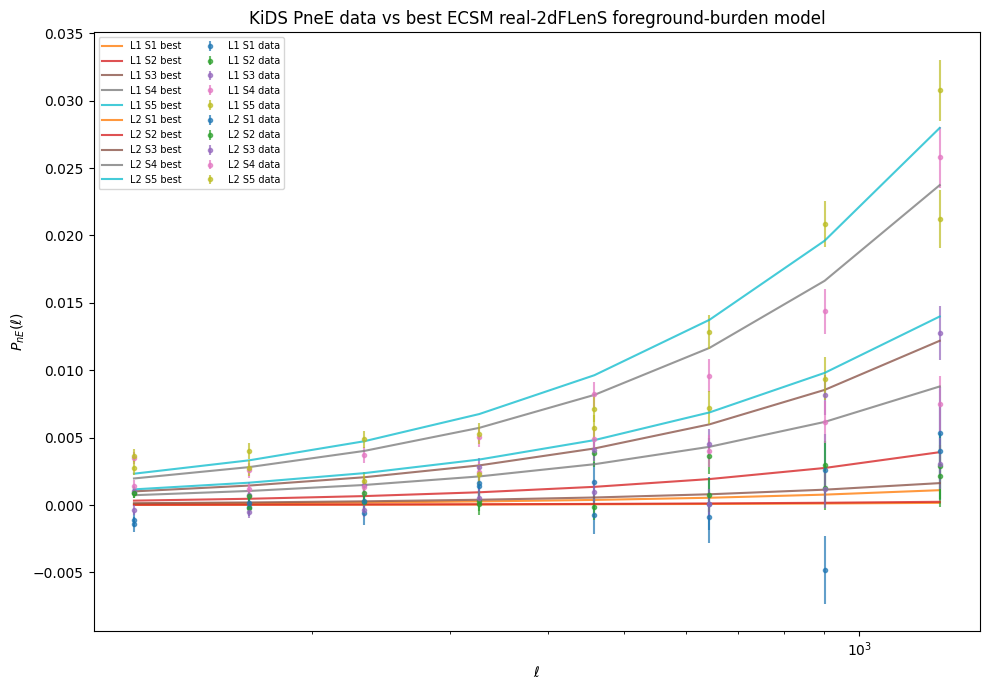

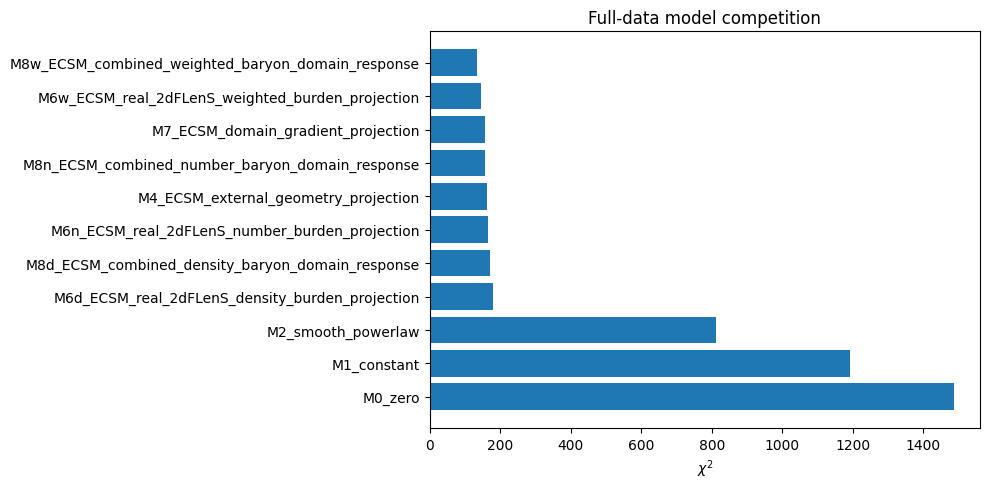

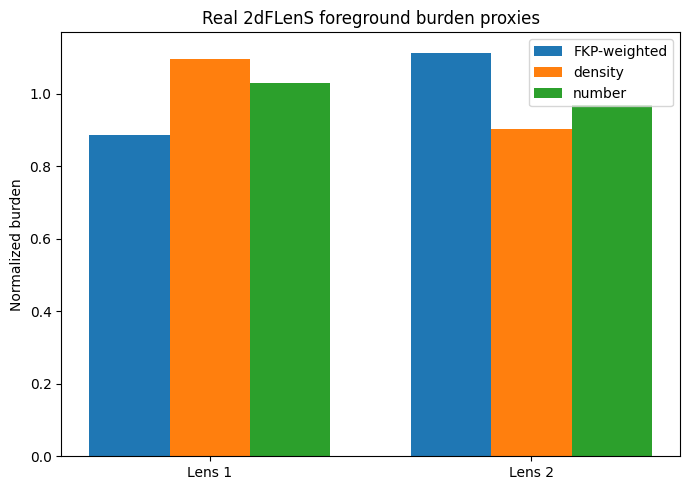

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarni

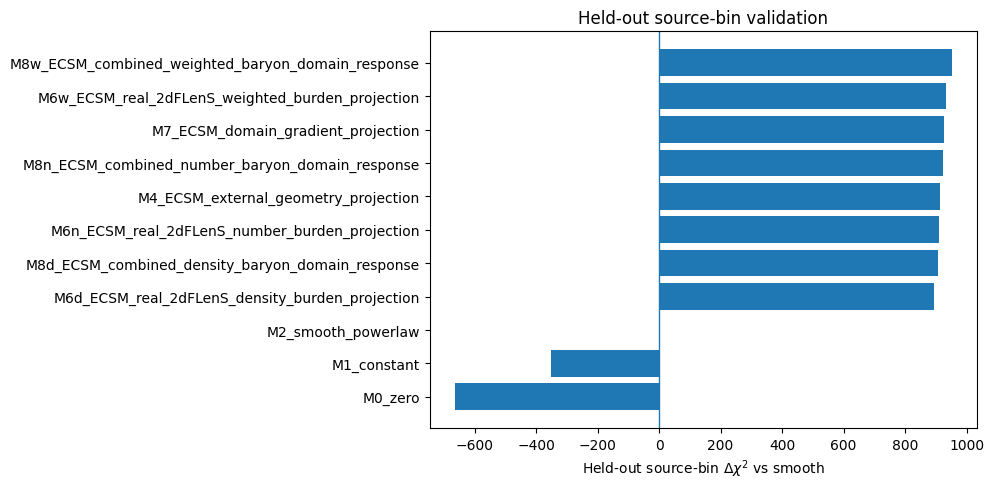

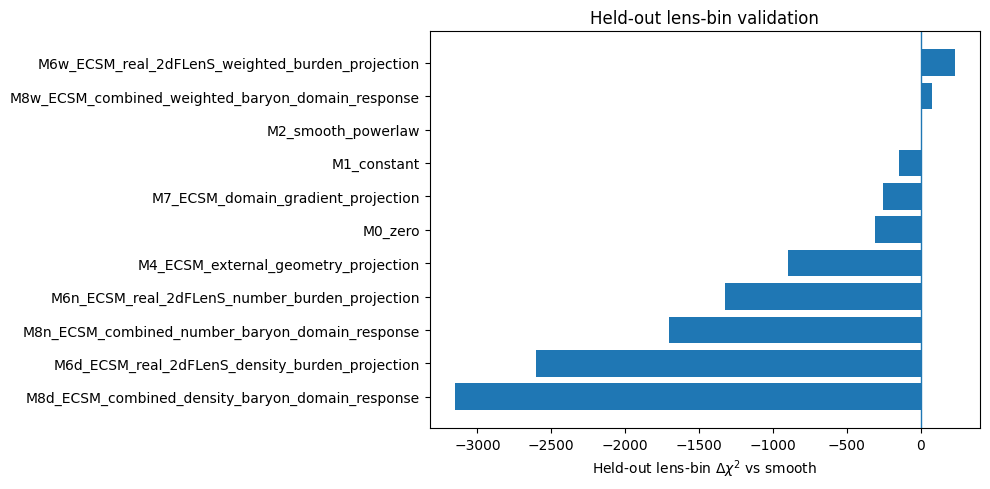

Figures saved in: /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures
Files:
- /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures/v12_best_model_by_lens_source.png
- /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures/v12_full_data_chi2_comparison.png
- /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures/v12_heldout_lens_delta_chi2_vs_smooth.png
- /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures/v12_heldout_source_delta_chi2_vs_smooth.png
- /content/ecsm_kids_v12_real_2dflens_foreground_burden_out/figures/v12_real_2dflens_burden_proxies.png


In [11]:
# CELL 09 — PREDICTIONS AND FIGURES
banner("CELL 09 — PREDICTIONS AND FIGURES")

pred_df = pd.read_csv(TAB / "v12_predictions_full_data_real_2dflens.csv")
res = pd.read_csv(TAB / "v12_full_data_model_competition_real_2dflens.csv")
source_summary = pd.read_csv(TAB / "v12_heldout_source_bin_summary_real_2dflens.csv")
lens_summary = pd.read_csv(TAB / "v12_heldout_lens_bin_summary_real_2dflens.csv")

best_model_name = res.iloc[0]["model"]
print("Best model:", best_model_name)

# Figure 1: data and best model by lens/source bin.
plt.figure(figsize=(10, 7))
for (lb, sb), sub in pred_df.groupby(["lens_bin", "source_bin"]):
    sub = sub.sort_values("ell")
    label_data = f"L{lb} S{sb} data"
    label_pred = f"L{lb} S{sb} best"
    plt.errorbar(sub["ell"], sub["Pgk_E"], yerr=sub["sigma_diag"], fmt="o", markersize=3, alpha=0.7, label=label_data)
    plt.plot(sub["ell"], sub[best_model_name], linewidth=1.5, alpha=0.8, label=label_pred)
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$P_{nE}(\ell)$")
plt.title("KiDS PneE data vs best ECSM real-2dFLenS foreground-burden model")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
fig1 = FIG / "v12_best_model_by_lens_source.png"
plt.savefig(fig1, dpi=200)
plt.show()

# Figure 2: full-data chi2 comparison.
plt.figure(figsize=(10, 5))
plot_res = res.sort_values("chi2", ascending=True)
plt.barh(plot_res["model"], plot_res["chi2"])
plt.gca().invert_yaxis()
plt.xlabel(r"$\chi^2$")
plt.title("Full-data model competition")
plt.tight_layout()
fig2 = FIG / "v12_full_data_chi2_comparison.png"
plt.savefig(fig2, dpi=200)
plt.show()

# Figure 3: real 2dFLenS foreground burden proxies by lens bin.
lens_burden = pd.read_csv(TAB / "v12_2dflens_lensbin_foreground_burden.csv")
plt.figure(figsize=(7, 5))
x = np.arange(len(lens_burden))
width = 0.25
plt.bar(x - width, lens_burden["weighted_burden_norm"], width, label="FKP-weighted")
plt.bar(x, lens_burden["density_burden_norm"], width, label="density")
plt.bar(x + width, lens_burden["number_burden_norm"], width, label="number")
plt.xticks(x, [f"Lens {int(v)}" for v in lens_burden["lens_bin"]])
plt.ylabel("Normalized burden")
plt.title("Real 2dFLenS foreground burden proxies")
plt.legend()
plt.tight_layout()
fig3 = FIG / "v12_real_2dflens_burden_proxies.png"
plt.savefig(fig3, dpi=200)
plt.show()

# Figure 4: CV summary vs smooth.
cv_plot = source_summary.copy()
plt.figure(figsize=(10,5))
plt.barh(cv_plot["model"], cv_plot["total_delta_chi2_vs_smooth"])
plt.axvline(0, linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel(r"Held-out source-bin $\Delta\chi^2$ vs smooth")
plt.title("Held-out source-bin validation")
plt.tight_layout()
fig4 = FIG / "v12_heldout_source_delta_chi2_vs_smooth.png"
plt.savefig(fig4, dpi=200)
plt.show()

# Figure 5: lens-bin CV summary.
cv_plot = lens_summary.copy()
plt.figure(figsize=(10,5))
plt.barh(cv_plot["model"], cv_plot["total_delta_chi2_vs_smooth"])
plt.axvline(0, linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel(r"Held-out lens-bin $\Delta\chi^2$ vs smooth")
plt.title("Held-out lens-bin validation")
plt.tight_layout()
fig5 = FIG / "v12_heldout_lens_delta_chi2_vs_smooth.png"
plt.savefig(fig5, dpi=200)
plt.show()

print("Figures saved in:", FIG)
print("Files:")
for p in sorted(FIG.glob("*.png")):
    print("-", p)

In [12]:
# CELL 10 — README / SUMMARY REPORT / ZIP OUTPUTS
banner("CELL 10 — README / SUMMARY REPORT / ZIP OUTPUTS")

res = pd.read_csv(TAB / "v12_full_data_model_competition_real_2dflens.csv")
source_summary = pd.read_csv(TAB / "v12_heldout_source_bin_summary_real_2dflens.csv")
lens_summary = pd.read_csv(TAB / "v12_heldout_lens_bin_summary_real_2dflens.csv")
lens_burden = pd.read_csv(TAB / "v12_2dflens_lensbin_foreground_burden.csv")

best = res.iloc[0].to_dict()
readme = f"""
# {RUN_NAME}

## Purpose

This clean V12 notebook tests the ECSM KiDS weak-lensing response using the actual 2dFLenS foreground lens catalogues rather than the earlier LePhare fallback catalogue.

The main response chain tested is:

```text
KiDS lens/source geometry
× real 2dFLenS foreground-lens burden
× domain-boundary-gradient response
× finite-response ell kernel
→ predicted KiDS-1000 PneE galaxy--galaxy lensing bandpower
```

## Input foreground catalogues

Four user-supplied 2dFLenS KiDS foreground-lens tarballs were used:

```text
{chr(10).join([f'- {k}: {v}' for k,v in TARBALLS.items()])}
```

The notebook extracts the four real `data_*` catalogues and rejects the 400 random catalogues.

## Foreground catalogue summary

{lens_burden.to_markdown(index=False)}

## KiDS observable

- Repository: `{KIDS_REPO_URL}`
- Observable: `PneE`
- Data points: `{len(kids_model)}`
- Lens bins: `{sorted(kids_model['lens_bin'].unique().tolist())}`
- Source bins: `{sorted(kids_model['source_bin'].unique().tolist())}`
- Ell range: `{kids_model['ell'].min():.6f}` to `{kids_model['ell'].max():.6f}`
- Covariance method: `{cov_method}`

## Full-data model competition

{res.to_markdown(index=False)}

## Held-out source-bin validation

{source_summary.to_markdown(index=False)}

## Held-out lens-bin validation

{lens_summary.to_markdown(index=False)}

## Best full-data model

```json
{json.dumps(best, indent=2, default=str)}
```

## Interpretation guardrail

V12 is the first clean ECSM KiDS weak-lensing notebook in this branch that uses real 2dFLenS foreground object catalogues for the burden construction. It remains a bandpower-level response test, not a full first-principles shear-map calculation. The foreground catalogue provides redshift, sky position, FKP weight, target type, jackknife region, and coordinate proxies; it does not provide direct stellar masses for every foreground lens. The strongest defensible claim is therefore about real foreground-count/weight/density burden response, not direct stellar-mass response.

## Exported products

- `tables/v12_2dflens_lensbin_foreground_burden.csv`
- `tables/v12_kids_pnee_with_real_2dflens_drivers.csv`
- `tables/v12_full_data_model_competition_real_2dflens.csv`
- `tables/v12_heldout_source_bin_summary_real_2dflens.csv`
- `tables/v12_heldout_lens_bin_summary_real_2dflens.csv`
- `figures/*.png`

Generated: {datetime.utcnow().isoformat()} UTC
""".strip()

readme_path = OUT / "README.md"
readme_path.write_text(readme)
print(readme)
print("\nSaved:", readme_path)

zip_path = Path(f"/content/{RUN_NAME}_outputs.zip")
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUT)
print("\nZIP ready:", zip_path)
print("Size MB:", round(zip_path.stat().st_size/1e6, 3))

# Optional Drive copy.
drive_dir = Path("/content/drive/MyDrive/ECSM_KiDS_data")
if drive_dir.exists():
    drive_dir.mkdir(parents=True, exist_ok=True)
    dst = drive_dir / zip_path.name
    shutil.copy2(zip_path, dst)
    print("Copied to Drive:", dst)
else:
    print("Drive output folder not found; ZIP remains in /content.")


CELL 10 — README / SUMMARY REPORT / ZIP OUTPUTS
# ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden

## Purpose

This clean V12 notebook tests the ECSM KiDS weak-lensing response using the actual 2dFLenS foreground lens catalogues rather than the earlier LePhare fallback catalogue.

The main response chain tested is:

```text
KiDS lens/source geometry
× real 2dFLenS foreground-lens burden
× domain-boundary-gradient response
× finite-response ell kernel
→ predicted KiDS-1000 PneE galaxy--galaxy lensing bandpower
```

## Input foreground catalogues

Four user-supplied 2dFLenS KiDS foreground-lens tarballs were used:

```text
- z1_kidsn: /content/drive/MyDrive/data_2dfbz1_kidsn_160105_rat.tar.gz
- z1_kidss: /content/drive/MyDrive/data_2dfbz1_kidss_160105_rat.tar.gz
- z3_kidsn: /content/drive/MyDrive/data_2dfbz3_kidsn_160105_rat.tar.gz
- z3_kidss: /content/drive/MyDrive/data_2dfbz3_kidss_160105_rat.tar.gz
```

The notebook extracts the four real `data_*` catalogues and rejects the 400 random cat

/tmp/ipykernel_1690/5179873.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  Generated: {datetime.utcnow().isoformat()} UTC
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



ZIP ready: /content/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip
Size MB: 294.461
Copied to Drive: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip
